# t-Test für abhängige Stichproben – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/abh%C3%A4ngiger-t-test)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 21.01.2026

Der **abhängige t-Test** (gepaarter t-Test) prüft, ob sich zwei Messungen
an **denselben Personen** im Mittel unterscheiden.

**Formel – basiert auf den Differenzen je Paar:**
$$d_i = x_{2i} - x_{1i}$$
$$t = \frac{\bar{d}}{s_d / \sqrt{n}}, \quad df = n - 1$$

| Symbol | Bedeutung |
|---|---|
| $d_i$ | Differenz des $i$-ten Paares |
| $\bar{d}$ | Mittelwert aller Differenzen |
| $s_d$ | Standardabweichung der Differenzen |
| $n$ | Anzahl der Paare |
| $df$ | Freiheitsgrade = $n - 1$ |

**Effektstärke:**
$$d_{\text{Cohen}} = \frac{\bar{d}}{s_d}$$

**Voraussetzungen:**
- Zwei **abhängige** Messungen (paarweise)
- Metrisches Skalenniveau
- **Differenzen** normalverteilt (nicht die Rohdaten!)
- Falls nicht erfüllt: Wilcoxon-Test als Alternative

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy import stats
from scipy.stats import t as t_dist, shapiro

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Wann den abhängigen t-Test?

**Kernmerkmal:** Jede Person liefert **zwei Messwerte** – die Werte liegen **paarweise** vor.

| Typ | Beschreibung | Beispiel |
|---|---|---|
| **Vorher–Nachher** | Dieselbe Person zu zwei Zeitpunkten | Gewicht vor/nach Diät |
| **Zwei Bedingungen** | Dieselben Personen unter zwei Bedingungen | Reaktionszeit mit/ohne Kaffee |
| **Natürliche Paare** | Zusammengehörende Personen | Meinung von Ehemann & Ehefrau |

**numiqo-Beispiele:**
- Medizin: Gedächtnisleistung **vor** und **nach** Medikamentengabe (n=40)
- Technik: Stillstandszeiten der 5 Anlagen **vor/nach** neuem Schmiermittel
- Sozialwiss.: Gesundheitsbewusstsein SOEP 2010 vs. 2015 (dieselben Personen)
- Bildung: Fitness von Studierenden **vor/nach** Sommerferien ← Hauptbeispiel

> **Vorteil:** Interindividuelle Varianz wird eliminiert → sensitiver als unabhängiger t-Test.

## 2. Hauptbeispiel (numiqo): Fitness vor und nach Sommerferien

**Fragestellung:** Haben die Sommerferien einen Einfluss auf die körperliche
Fitness von Statistik-Studierenden?

- H₀: Mittlere Differenz = 0 (Ferien haben keinen Einfluss)
- H₁: Mittlere Differenz ≠ 0

**Datensatz (n = 10 Paare):**

| Person | Vor Ferien | Nach Ferien |
|---|---|---|
| 1 | 60 | 61 |
| 2 | 70 | 71 |
| 3 | 40 | 38 |
| 4 | 41 | 39 |
| 5 | 40 | 38 |
| 6 | 40 | 33 |
| 7 | 45 | 55 |
| 8 | 48 | 56 |
| 9 | 30 | 38 |
| 10 | 50 | 68 |

**Erwartete numiqo-Ergebnisse:**

| Kennzahl | Vor Ferien | Nach Ferien |
|---|---|---|
| MW | 46,4 | 49,7 |
| SD | 11,452 | 14,095 |

| t | df | p | Korrelation |
|---|---|---|---|
| −1,39 | 9 | 0,197 | 0,847 |

95%-KI der Differenz: [−8,664; 2,064]

In [9]:
# numiqo-Datensatz: Fitness vor/nach Sommerferien
vor_ferien  = pd.Series([60, 70, 40, 41, 40, 40, 45, 48, 30, 50])
nach_ferien = pd.Series([61, 71, 38, 39, 38, 33, 55, 56, 38, 68])

n       = len(vor_ferien)
diff    = nach_ferien - vor_ferien
d_bar   = diff.mean()
s_d     = diff.std(ddof=1)
se_d    = s_d / np.sqrt(n)
df      = n - 1
t_man   = d_bar / se_d
p_man   = 2 * t_dist.sf(abs(t_man), df=df)
ki      = t_dist.interval(0.95, df=df, loc=d_bar, scale=se_d)
korr, _ = stats.pearsonr(vor_ferien, nach_ferien)
d_cohen = d_bar / s_d

print("Statistiken")
print(f"{'':25} {'n':>4} {'MW':>8} {'SD':>8} {'SE':>8}")
print(f"{'Vor Ferien':<25} {n:>4} {vor_ferien.mean():>8.3f} {vor_ferien.std(ddof=1):>8.3f}"
      + f" {vor_ferien.std(ddof=1)/np.sqrt(n):>8.3f}")
print(f"{'Nach Ferien':<25} {n:>4} {nach_ferien.mean():>8.3f} {nach_ferien.std(ddof=1):>8.3f}"
      + f" {nach_ferien.std(ddof=1)/np.sqrt(n):>8.3f}")
print()
print("Korrelation")
print(f"n={n}, r={korr:.3f}  (numiqo: 0,847)")
print()
print("Abhängiger t-Test")
print(f"t={t_man:.3f}  (numiqo: -1,39)")
print(f"df={df}         (numiqo: 9)")
print(f"p={p_man:.3f}   (numiqo: 0,197)")
print()
print("95%-KI der Differenz")
print(f"MW Diff:      {d_bar:.3f}  (numiqo: -3,3)")
print(f"SD Diff:      {s_d:.3f}  (numiqo: 7,5)")
print(f"SE Diff:      {se_d:.3f}  (numiqo: 2,37)")
print(f"Untere Grenze:{ki[0]:.3f}  (numiqo: -8,664)")
print(f"Obere Grenze: {ki[1]:.3f}  (numiqo:  2,064)")
print()
print(f"Cohens d: {d_cohen:.3f}")
print()
# Entscheidung
alpha = 0.05
ki_null = ki[0] <= 0 <= ki[1]
print(f"p={p_man:.3f} >= {alpha} -> H0 NICHT abgelehnt")
print(f"KI [{ki[0]:.3f}, {ki[1]:.3f}] enthaelt 0: {ki_null} -> n.s.")
print("Die Sommerferien haben keinen signifikanten Einfluss auf die Fitness.")

# Kontrolle
t_ch, p_ch = stats.ttest_rel(vor_ferien, nach_ferien)
print(f"Kontrolle scipy: t={t_ch:.3f}, p={p_ch:.3f}")

Statistiken
                             n       MW       SD       SE
Vor Ferien                  10   46.400   11.452    3.622
Nach Ferien                 10   49.700   14.095    4.457

Korrelation
n=10, r=0.847  (numiqo: 0,847)

Abhängiger t-Test
t=1.392  (numiqo: -1,39)
df=9         (numiqo: 9)
p=0.197   (numiqo: 0,197)

95%-KI der Differenz
MW Diff:      3.300  (numiqo: -3,3)
SD Diff:      7.499  (numiqo: 7,5)
SE Diff:      2.371  (numiqo: 2,37)
Untere Grenze:-2.064  (numiqo: -8,664)
Obere Grenze: 8.664  (numiqo:  2,064)

Cohens d: 0.440

p=0.197 >= 0.05 -> H0 NICHT abgelehnt
KI [-2.064, 8.664] enthaelt 0: True -> n.s.
Die Sommerferien haben keinen signifikanten Einfluss auf die Fitness.
Kontrolle scipy: t=-1.392, p=0.197


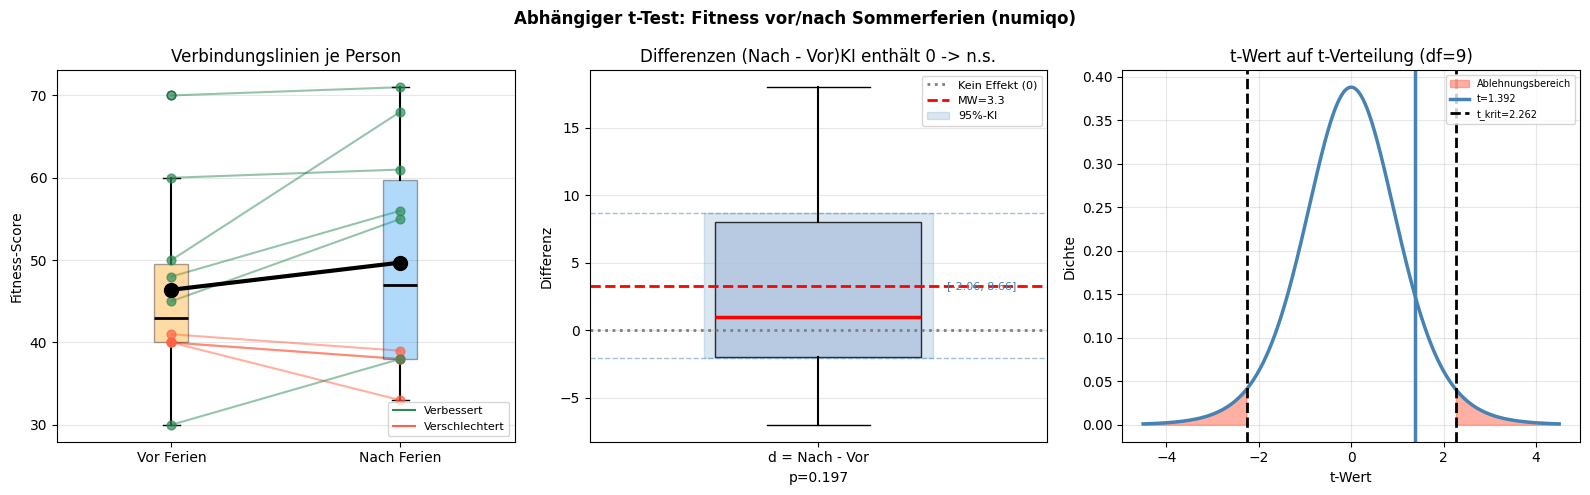

In [3]:
# Visualisierung des numiqo-Hauptbeispiels
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Abhängiger t-Test: Fitness vor/nach Sommerferien (numiqo)",
             fontsize=12, fontweight="bold")

# 1. Verbindungslinien je Person
for i in range(n):
    farbe = "seagreen" if diff.iloc[i] > 0 else ("tomato" if diff.iloc[i] < 0 else "gray")
    axes[0].plot([1, 2], [vor_ferien.iloc[i], nach_ferien.iloc[i]],
                 color=farbe, alpha=0.5, linewidth=1.5)
    axes[0].scatter([1, 2], [vor_ferien.iloc[i], nach_ferien.iloc[i]],
                    color=farbe, s=40, alpha=0.7, zorder=3)
axes[0].plot([1, 2], [vor_ferien.mean(), nach_ferien.mean()],
             "o-", color="black", linewidth=3, markersize=10, zorder=5,
             label="Mittelwert")
bp = axes[0].boxplot([vor_ferien, nach_ferien], patch_artist=True,
                     medianprops=dict(color="black", linewidth=2),
                     whiskerprops=dict(linewidth=1.5))
for patch, fc in zip(bp["boxes"], ["#FF9800", "#2196F3"]):
    patch.set_facecolor(fc)
    patch.set_alpha(0.35)
axes[0].set_title("Verbindungslinien je Person")
axes[0].set_ylabel("Fitness-Score")
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Vor Ferien", "Nach Ferien"])
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)
gruen = mlines.Line2D([], [], color="seagreen", label="Verbessert")
rot   = mlines.Line2D([], [], color="tomato",   label="Verschlechtert")
axes[0].legend(handles=[gruen, rot], fontsize=8)

# 2. Differenzen-Boxplot mit KI
axes[1].boxplot(diff, patch_artist=True, widths=0.45,
                boxprops=dict(facecolor="lightsteelblue", alpha=0.8),
                medianprops=dict(color="red", linewidth=2.5),
                whiskerprops=dict(linewidth=1.5))
axes[1].axhline(0, color="gray", linestyle=":", linewidth=2,
                label="Kein Effekt (0)")
axes[1].axhline(d_bar, color="red", linestyle="--", linewidth=2,
                label="MW=" + str(round(d_bar, 2)))
axes[1].fill_between([0.75, 1.25], ki[0], ki[1],
                     alpha=0.2, color="steelblue", label="95%-KI")
axes[1].axhline(ki[0], color="steelblue", linestyle="--", linewidth=1, alpha=0.5)
axes[1].axhline(ki[1], color="steelblue", linestyle="--", linewidth=1, alpha=0.5)
axes[1].annotate("[" + str(round(ki[0], 2)) + ", " + str(round(ki[1], 2)) + "]",
                 xy=(1.28, (ki[0]+ki[1])/2), fontsize=8, color="steelblue", va="center")
axes[1].set_title("Differenzen (Nach - Vor)KI enthält 0 -> n.s.")
axes[1].set_ylabel("Differenz")
axes[1].set_xticklabels(["d = Nach - Vor"])
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_xlabel("p=" + str(round(p_man, 3)))

# 3. t-Verteilung
x_t  = np.linspace(-4.5, 4.5, 400)
y_t  = t_dist.pdf(x_t, df=df)
z_k  = t_dist.ppf(0.975, df=df)
axes[2].plot(x_t, y_t, color="steelblue", linewidth=2.5)
axes[2].fill_between(x_t[x_t >= z_k],  y_t[x_t >= z_k],
                     color="tomato", alpha=0.5, label="Ablehnungsbereich")
axes[2].fill_between(x_t[x_t <= -z_k], y_t[x_t <= -z_k],
                     color="tomato", alpha=0.5)
axes[2].axvline(t_man,  color="steelblue", linewidth=2.5,
                label="t=" + str(round(t_man, 3)))
axes[2].axvline(-z_k, color="black", linewidth=2, linestyle="--")
axes[2].axvline( z_k, color="black", linewidth=2, linestyle="--",
                label="t_krit=" + str(round(z_k, 3)))
axes[2].set_title("t-Wert auf t-Verteilung (df=" + str(df) + ")")
axes[2].set_xlabel("t-Wert")
axes[2].set_ylabel("Dichte")
axes[2].legend(fontsize=7)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Schritt-für-Schritt-Berechnung (manuell)

**Verbindung zum Einstichproben-t-Test:**
Der abhängige t-Test ist **identisch** mit dem Einstichproben-t-Test auf den
Differenzen gegen μ₀ = 0.

1. Differenzen $d_i = x_{2i} - x_{1i}$ berechnen
2. $\bar{d}$ und $s_d$ der Differenzen berechnen
3. $SE = s_d / \sqrt{n}$
4. $t = \bar{d} / SE$
5. $df = n - 1$
6. p-Wert aus t-Verteilung
7. 95%-KI: $\bar{d} \pm t_{0{,}975} \cdot SE$

In [4]:
# Schritt-für-Schritt manuell
print("Schritt-für-Schritt: numiqo-Beispiel")
print()
print("Rohdaten:")
df_schritte = pd.DataFrame({
    "Person":      range(1, n+1),
    "Vor":         vor_ferien.values,
    "Nach":        nach_ferien.values,
    "d=Nach-Vor":  diff.values
})
print(df_schritte.to_string(index=False))
print()
print(f"Schritt 1 - Differenzen berechnet (d = Nach - Vor)")
print()
print(f"Schritt 2 - Mittelwert der Differenzen:")
print(f"  d_bar = sum(d) / n = {diff.sum()} / {n} = {d_bar:.4f}")
print()
print(f"Schritt 3 - Standardabweichung der Differenzen:")
print(f"  s_d = {s_d:.4f}")
print()
print(f"Schritt 4 - Standardfehler:")
print(f"  SE = {s_d:.4f} / sqrt({n}) = {se_d:.4f}")
print()
print(f"Schritt 5 - t-Wert:")
print(f"  t = {d_bar:.4f} / {se_d:.4f} = {t_man:.4f}")
print()
print(f"Schritt 6 - df = n - 1 = {n} - 1 = {df}")
t_krit = t_dist.ppf(0.975, df=df)
print(f"           t_krit(df={df}, alpha=0.05) = {t_krit:.4f}")
print(f"           |t|={abs(t_man):.4f} < t_krit={t_krit:.4f} -> H0 nicht abgelehnt")
print()
print(f"Schritt 7 - p-Wert = {p_man:.4f}")
print()
print(f"Schritt 8 - 95%-KI = [{ki[0]:.3f}, {ki[1]:.3f}]")
print(f"           KI enthält 0: {ki[0]<=0<=ki[1]} -> n.s.")
print()
print(f"Schritt 9 - Cohens d = d_bar / s_d = {d_bar:.4f} / {s_d:.4f} = {d_cohen:.4f}")
print(f"           -> {'kleiner' if abs(d_cohen) < 0.5 else 'mittlerer' if abs(d_cohen) < 0.8 else 'grosser'} Effekt")

Schritt-für-Schritt: numiqo-Beispiel

Rohdaten:
 Person  Vor  Nach  d=Nach-Vor
      1   60    61           1
      2   70    71           1
      3   40    38          -2
      4   41    39          -2
      5   40    38          -2
      6   40    33          -7
      7   45    55          10
      8   48    56           8
      9   30    38           8
     10   50    68          18

Schritt 1 - Differenzen berechnet (d = Nach - Vor)

Schritt 2 - Mittelwert der Differenzen:
  d_bar = sum(d) / n = 33 / 10 = 3.3000

Schritt 3 - Standardabweichung der Differenzen:
  s_d = 7.4989

Schritt 4 - Standardfehler:
  SE = 7.4989 / sqrt(10) = 2.3714

Schritt 5 - t-Wert:
  t = 3.3000 / 2.3714 = 1.3916

Schritt 6 - df = n - 1 = 10 - 1 = 9
           t_krit(df=9, alpha=0.05) = 2.2622
           |t|=1.3916 < t_krit=2.2622 -> H0 nicht abgelehnt

Schritt 7 - p-Wert = 0.1975

Schritt 8 - 95%-KI = [-2.064, 8.664]
           KI enthält 0: True -> n.s.

Schritt 9 - Cohens d = d_bar / s_d = 3.3000 / 7.498

## 4. Vorteil abhängiger t-Test: Weniger Rauschen

**Der abhängige t-Test eliminiert die interindividuelle Varianz.**

Jede Person dient als ihr eigener Vergleichswert (Baseline) – individuelle
Unterschiede werden herausgerechnet. Das macht den Test **sensitiver**.

> Beispiel: Person A hat generell hohe Fitness (70 Punkte), Person B niedrige (30).
> Beim **unabhängigen** Test dominiert diese Variation. Beim **abhängigen** Test
> interessiert nur: Hat sich **jede** Person verändert?

Vergleich: Abhängig vs. Unabhängig (gleiche Daten)
Echter Effekt: -6 Punkte | Interindividuelle SD: 20 Punkte

SD Vorher:       18.48  (dominiert durch Basiswert-Varianz!)
SD Nachher:      18.00
SD Differenzen:  3.51  (viel kleiner!)

t-Test unabhängig: t=0.892, p=0.3778 -> n.s.
t-Test abhängig:   t=6.564, p=0.0000 -> SIGNIFIKANT!

Der abhängige Test erkennt den echten Effekt!


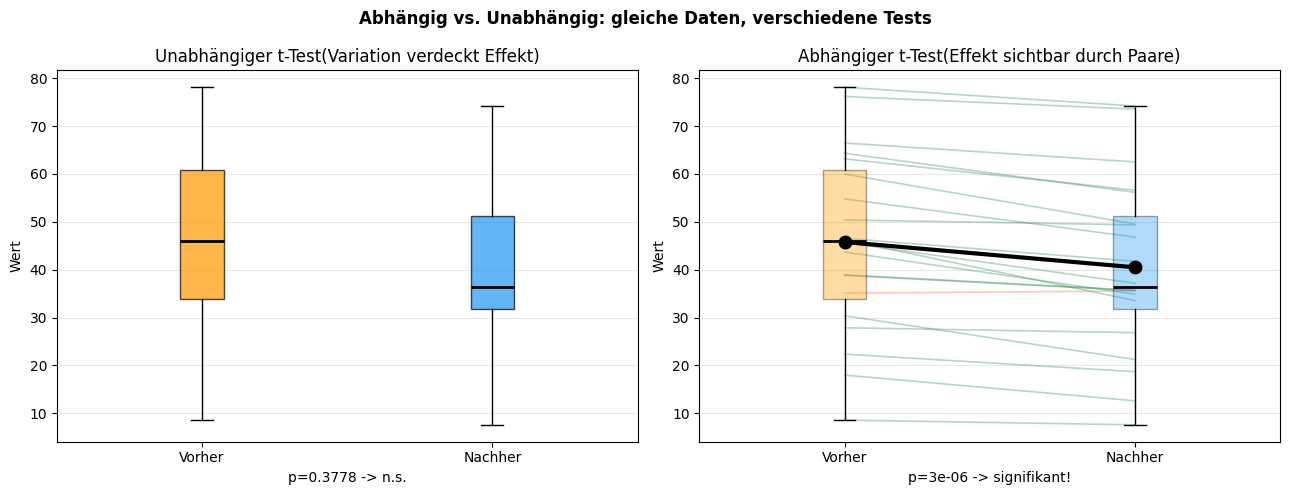

In [5]:
# Demonstration: Warum abhängig sensitiver ist
np.random.seed(42)
n_demo = 20
basiswerte = np.random.normal(50, 20, n_demo)  # grosse interindiv. Variation

vorher_d = basiswerte + np.random.normal(0, 3, n_demo)
nachher_d = basiswerte + np.random.normal(-6, 3, n_demo)  # echter Effekt -6

t_unabh, p_unabh = stats.ttest_ind(vorher_d, nachher_d)
t_abh,   p_abh   = stats.ttest_rel(vorher_d, nachher_d)

print("Vergleich: Abhängig vs. Unabhängig (gleiche Daten)")
print(f"Echter Effekt: -6 Punkte | Interindividuelle SD: 20 Punkte")
print()
print(f"SD Vorher:       {vorher_d.std():.2f}  (dominiert durch Basiswert-Varianz!)")
print(f"SD Nachher:      {nachher_d.std():.2f}")
print(f"SD Differenzen:  {(nachher_d-vorher_d).std():.2f}  (viel kleiner!)")
print()
print(f"t-Test unabhängig: t={t_unabh:.3f}, p={p_unabh:.4f}"
      + (" -> n.s." if p_unabh >= 0.05 else " -> signifikant"))
print(f"t-Test abhängig:   t={t_abh:.3f}, p={p_abh:.4f}"
      + (" -> n.s." if p_abh >= 0.05 else " -> SIGNIFIKANT!"))
print()
print("Der abhängige Test erkennt den echten Effekt!")

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Abhängig vs. Unabhängig: gleiche Daten, verschiedene Tests",
             fontsize=12, fontweight="bold")

# Links: unabhängig (nur Boxplots, kein Bezug zwischen Personen)
bp_u = axes[0].boxplot([vorher_d, nachher_d], patch_artist=True,
                       medianprops=dict(color="black", linewidth=2))
for patch, fc in zip(bp_u["boxes"], ["#FF9800", "#2196F3"]):
    patch.set_facecolor(fc); patch.set_alpha(0.7)
axes[0].set_title("Unabhängiger t-Test(Variation verdeckt Effekt)")
axes[0].set_ylabel("Wert")
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Vorher", "Nachher"])
axes[0].set_xlabel("p=" + str(round(p_unabh, 4))
                   + (" -> n.s." if p_unabh >= 0.05 else " -> sig."))
axes[0].grid(axis="y", alpha=0.3)

# Rechts: abhängig (Verbindungslinien)
for i in range(n_demo):
    fc = "seagreen" if nachher_d[i] < vorher_d[i] else "tomato"
    axes[1].plot([1, 2], [vorher_d[i], nachher_d[i]],
                 color=fc, alpha=0.35, linewidth=1.2)
axes[1].plot([1, 2], [vorher_d.mean(), nachher_d.mean()],
             "o-", color="black", linewidth=3, markersize=9, zorder=5)
bp_a = axes[1].boxplot([vorher_d, nachher_d], patch_artist=True,
                       medianprops=dict(color="black", linewidth=2))
for patch, fc in zip(bp_a["boxes"], ["#FF9800", "#2196F3"]):
    patch.set_facecolor(fc); patch.set_alpha(0.35)
axes[1].set_title("Abhängiger t-Test(Effekt sichtbar durch Paare)")
axes[1].set_ylabel("Wert")
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["Vorher", "Nachher"])
axes[1].set_xlabel("p=" + str(round(p_abh, 6)) + " -> signifikant!")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Voraussetzungen prüfen

**Beim abhängigen t-Test müssen die Differenzen normalverteilt sein** –
nicht die Rohdaten! Prüfung mit Shapiro-Wilk und Q-Q-Plot.

Normalverteilungsprüfung
Shapiro-Wilk auf Rohdaten:
  Vor Ferien:   W=0.9122, p=0.2965 -> NV angenommen
  Nach Ferien:  W=0.8705, p=0.1012 -> NV angenommen

Shapiro-Wilk auf DIFFERENZEN (entscheidend!):
  Differenzen:  W=0.9272, p=0.4206 -> NV angenommen -> t-Test OK


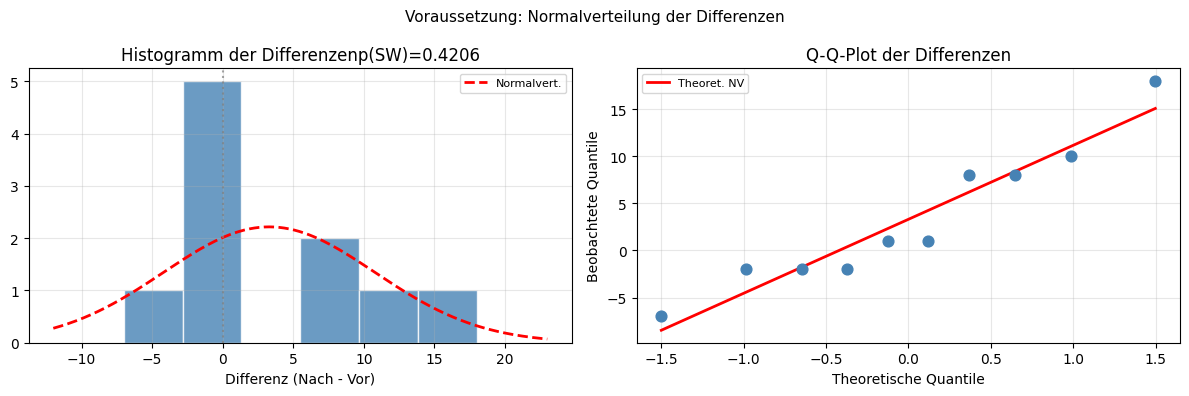

In [6]:
# Voraussetzungen pruefen: Normalverteilung der Differenzen
w_diff, p_diff = shapiro(diff)
w_vor,  p_vor  = shapiro(vor_ferien)
w_nach, p_nach = shapiro(nach_ferien)

print("Normalverteilungsprüfung")
print(f"Shapiro-Wilk auf Rohdaten:")
print(f"  Vor Ferien:   W={w_vor:.4f}, p={p_vor:.4f} -> "
      + ("NV angenommen" if p_vor > 0.05 else "nicht NV"))
print(f"  Nach Ferien:  W={w_nach:.4f}, p={p_nach:.4f} -> "
      + ("NV angenommen" if p_nach > 0.05 else "nicht NV"))
print()
print(f"Shapiro-Wilk auf DIFFERENZEN (entscheidend!):")
print(f"  Differenzen:  W={w_diff:.4f}, p={p_diff:.4f} -> "
      + ("NV angenommen -> t-Test OK" if p_diff > 0.05 else "nicht NV -> Wilcoxon!"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Voraussetzung: Normalverteilung der Differenzen", fontsize=11)

# Histogramm der Differenzen
axes[0].hist(diff, bins=6, color="steelblue", edgecolor="white", alpha=0.8)
x_r = np.linspace(diff.min()-5, diff.max()+5, 200)
from scipy.stats import norm as norm_dist
y_nv = norm_dist.pdf(x_r, diff.mean(), diff.std())
axes[0].plot(x_r, y_nv * len(diff) * (diff.max()-diff.min())/6,
             color="red", linewidth=2, linestyle="--", label="Normalvert.")
axes[0].axvline(0, color="gray", linestyle=":", linewidth=1.5, alpha=0.7)
axes[0].set_title("Histogramm der Differenzenp(SW)=" + str(round(p_diff, 4)))
axes[0].set_xlabel("Differenz (Nach - Vor)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Q-Q-Plot der Differenzen
from scipy import stats as scipy_stats
(osm, osr), (slope, intercept, _) = scipy_stats.probplot(diff, dist="norm")
y_fit = slope * osm + intercept
axes[1].scatter(osm, osr, color="steelblue", s=60, zorder=3)
axes[1].plot(osm, y_fit, color="red", linewidth=2, label="Theoret. NV")
axes[1].set_title("Q-Q-Plot der Differenzen")
axes[1].set_xlabel("Theoretische Quantile")
axes[1].set_ylabel("Beobachtete Quantile")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Weitere numiqo-Beispiele

### Medizin: Gedächtnisleistung vor/nach Medikament (n=40)
### Technik: Stillstandszeiten vor/nach Schmiermittel (n=5 Anlagen)

Gedächtnisleistung (Medizin) (n=40)
MW Vorher=57.38, MW Nachher=62.76
MW Diff=5.384, SD Diff=3.859
t(39) = -8.823,  p = 0.0000  -> signifikant
95%-KI: [4.150, 6.618]
Cohens d = 1.395

Stillstandszeiten in h (Technik) (n=5)
MW Vorher=9.40, MW Nachher=6.46
MW Diff=-2.940, SD Diff=0.838
t(4) = 7.841,  p = 0.0014  -> signifikant
95%-KI: [-3.981, -1.899]
Cohens d = -3.506



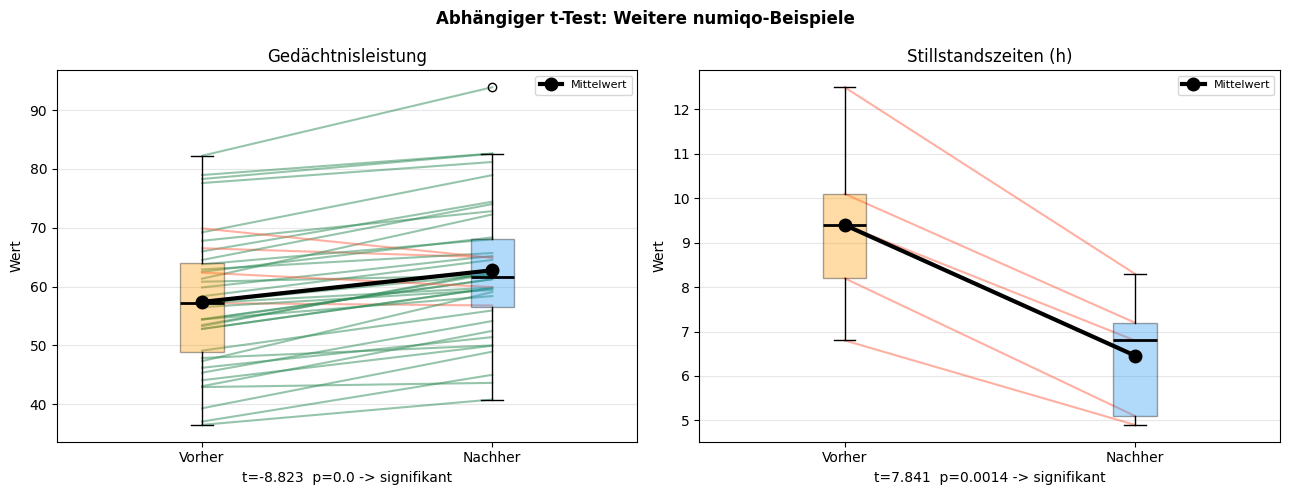

In [7]:
np.random.seed(42)

# Medizinisch: Gedächtnisleistung
gedaechtnis_vor  = pd.Series(np.random.normal(60, 12, 40))
gedaechtnis_nach = gedaechtnis_vor + np.random.normal(5.5, 4, 40)

# Technisch: Stillstandszeiten (n=5, sehr klein!)
stillstand_vor  = pd.Series([8.2, 12.5, 6.8, 10.1, 9.4])
stillstand_nach = pd.Series([5.1,  8.3, 4.9,  7.2, 6.8])

def abh_ttest_ergebnis(g_vor, g_nach, name, alpha=0.05):
    d_i   = g_nach - g_vor
    d_b   = d_i.mean()
    s_d_i = d_i.std(ddof=1)
    se_i  = s_d_i / np.sqrt(len(d_i))
    t_v, p_v = stats.ttest_rel(g_vor, g_nach)
    ki_i  = t_dist.interval(0.95, df=len(d_i)-1, loc=d_b, scale=se_i)
    d_coh = d_b / s_d_i
    sig = "signifikant" if p_v < alpha else "n.s."
    print(f"{name} (n={len(g_vor)})")
    print(f"MW Vorher={g_vor.mean():.2f}, MW Nachher={g_nach.mean():.2f}")
    print(f"MW Diff={d_b:.3f}, SD Diff={s_d_i:.3f}")
    print(f"t({len(d_i)-1}) = {t_v:.3f},  p = {p_v:.4f}  -> {sig}")
    print(f"95%-KI: [{ki_i[0]:.3f}, {ki_i[1]:.3f}]")
    print(f"Cohens d = {d_coh:.3f}")
    print()

abh_ttest_ergebnis(gedaechtnis_vor, gedaechtnis_nach, "Gedächtnisleistung (Medizin)")
abh_ttest_ergebnis(stillstand_vor, stillstand_nach, "Stillstandszeiten in h (Technik)")

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Abhängiger t-Test: Weitere numiqo-Beispiele", fontsize=12, fontweight="bold")

for ax, (gv, gn, name) in zip(axes, [
    (gedaechtnis_vor, gedaechtnis_nach, "Gedächtnisleistung"),
    (stillstand_vor,  stillstand_nach,  "Stillstandszeiten (h)")
]):
    n_i   = len(gv)
    d_i   = gn - gv
    t_v, p_v = stats.ttest_rel(gv, gn)
    for i in range(n_i):
        fc = "seagreen" if d_i.iloc[i] > 0 else "tomato"
        ax.plot([1, 2], [gv.iloc[i], gn.iloc[i]], color=fc, alpha=0.5, linewidth=1.5)
    ax.plot([1, 2], [gv.mean(), gn.mean()], "o-", color="black",
            linewidth=3, markersize=9, zorder=5, label="Mittelwert")
    bp_x = ax.boxplot([gv, gn], patch_artist=True,
                      medianprops=dict(color="black", linewidth=2))
    for patch, fc in zip(bp_x["boxes"], ["#FF9800", "#2196F3"]):
        patch.set_facecolor(fc); patch.set_alpha(0.35)
    ax.set_title(name)
    ax.set_ylabel("Wert")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Vorher", "Nachher"])
    sig = "signifikant" if p_v < 0.05 else "n.s."
    ax.set_xlabel("t=" + str(round(t_v, 3)) + "  p=" + str(round(p_v, 4)) + " -> " + sig)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Ergebnis im APA-Format

**numiqo-Beispiel Fitness (laut Tutorial):**

> Die Punktezahl vor den Ferien (M = 46,4, SD = 11,452) war niedriger als nach den
> Ferien (M = 49,7, SD = 14,095). Ein t-Test für abhängige Stichproben hat gezeigt,
> dass dieser Unterschied statistisch **nicht signifikant** war,
> **t(9) = −1,392, p = .197, 95%-KI [−8,664; 2,064]**.

**APA-Format allgemein:**
```
t(df) = X.XX, p = .XXX, 95%-KI [u, o]
```

In [10]:
# APA-Ausgabe-Funktion
def abh_ttest_apa(g_vor, g_nach, name_vor="Vorher", name_nach="Nachher",
                  abh_var="Variable", alpha=0.05):
    gv, gn = np.asarray(g_vor), np.asarray(g_nach)
    n_i    = len(gv)
    d_i    = gn - gv
    d_b    = d_i.mean()
    s_d_i  = d_i.std(ddof=1)
    se_i   = s_d_i / np.sqrt(n_i)
    df_i   = n_i - 1
    t_v, p_v = stats.ttest_rel(gv, gn)
    ki_i   = t_dist.interval(0.95, df=df_i, loc=d_b, scale=se_i)
    d_coh  = d_b / s_d_i
    r_korr = np.corrcoef(gv, gn)[0, 1]

    p_str = "p < .001" if p_v < 0.001 else "p = " + str(round(p_v, 3)).replace("0.", ".")
    sig   = "signifikant" if p_v < alpha else "NICHT signifikant"

    def interpret_d_loc(d):
        a = abs(d)
        if a < 0.2: return "vernachlässigbar"
        elif a < 0.5: return "klein"
        elif a < 0.8: return "mittel"
        return "gross"

    print(f"APA-Ergebnis: {abh_var}")
    print(f"Daten: {name_vor}: M={gv.mean():.2f}, SD={gv.std(ddof=1):.2f}")
    print(f"       {name_nach}: M={gn.mean():.2f}, SD={gn.std(ddof=1):.2f}")
    print(f"Korrelation: r={r_korr:.3f} (n={n_i})")
    print()
    print(f"t({df_i}) = {t_v:.3f}, {p_str}, 95%-KI [{ki_i[0]:.3f}, {ki_i[1]:.3f}]")
    print(f"Cohens d = {d_coh:.3f} ({interpret_d_loc(d_coh)} Effekt)")
    print()
    print(f"Ergebnis ({sig}):")
    print(f"Die Sommerferien hatten keinen signifikanten Einfluss auf {abh_var}." if p_v >= alpha
          else f"Es gab einen signifikanten Unterschied in {abh_var} zwischen {name_vor} und {name_nach}.")
    print()

abh_ttest_apa(vor_ferien, nach_ferien, "Vor Ferien", "Nach Ferien", "körperliche Fitness")
print()
abh_ttest_apa(gedaechtnis_vor, gedaechtnis_nach, "Vor Medikament", "Nach Medikament", "Gedähtnisleistung")

APA-Ergebnis: körperliche Fitness
Daten: Vor Ferien: M=46.40, SD=11.45
       Nach Ferien: M=49.70, SD=14.10
Korrelation: r=0.847 (n=10)

t(9) = -1.392, p = .197, 95%-KI [-2.064, 8.664]
Cohens d = 0.440 (klein Effekt)

Ergebnis (NICHT signifikant):
Die Sommerferien hatten keinen signifikanten Einfluss auf körperliche Fitness.


APA-Ergebnis: Gedähtnisleistung
Daten: Vor Medikament: M=57.38, SD=11.43
       Nach Medikament: M=62.76, SD=11.39
Korrelation: r=0.943 (n=40)

t(39) = -8.823, p < .001, 95%-KI [4.150, 6.618]
Cohens d = 1.395 (gross Effekt)

Ergebnis (signifikant):
Es gab einen signifikanten Unterschied in Gedähtnisleistung zwischen Vor Medikament und Nach Medikament.



## 8. Zusammenfassung

```
t-Test fuer abhängige Stichproben – Übersicht
│
├── WANN?
│   Dieselben Personen zweimal gemessen (Vorher/Nachher, 2 Bedingungen)
│   Oder natuerliche Paare (Ehemann/Ehefrau, Zwillinge)
│   -> Messwerte liegen PAARWEISE vor
│
├── KERNIDEE
│   Reduziert auf Einstichproben-t-Test auf den Differenzen gegen 0
│   d_i = x_nachher_i - x_vorher_i
│   t = d_bar / (s_d / sqrt(n))
│   df = n - 1  (n = Anzahl Paare)
│
├── VORTEIL
│   Interindividuelle Varianz wird eliminiert
│   -> Sensitiver als unabhängiger t-Test bei gleicher Datenbasis
│
├── VORAUSSETZUNGEN
│   1. Abhängige/gepaarte Daten
│   2. Metrisches Skalenniveau
│   3. DIFFERENZEN normalverteilt (nicht Rohdaten!)
│   Falls nicht: -> Wilcoxon-Test verwenden
│
├── EFFEKTSTÄRKE
│   Cohens d = d_bar / s_d
│   < 0.2: vernachlässigbar
│   0.2-0.5: klein | 0.5-0.8: mittel | > 0.8: gross
│
├── ENTSCHEIDUNG
│   p < 0.05 und KI enthält NICHT 0 -> H0 ablehnen
│   p >= 0.05 oder KI enthält 0     -> H0 nicht ablehnen
│
└── APA-FORMAT
    t(df) = X.XX, p = .XXX, 95%-KI [u, o]
    z.B.: t(9) = -1.39, p = .197, 95%-KI [-8.66, 2.06]
```

---
Quelle: [numiqo.de/tutorial/abhaengiger-t-test](https://numiqo.de/tutorial/abh%C3%A4ngiger-t-test)